Categorical data ara of 2 types
1.Nominal(unorderd) : Male/Female
2.Ordinal(Orderd) : Bad>Good>Excellent

Here encoding means converting categorical data to numerical

In [1]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)
n=50
df = pd.DataFrame({
    #Nominal
    "Gender": np.random.choice(["Male", "Female"], size=n),
    "Color": np.random.choice(["Red", "Blue", "Green", "Yellow"], size=n),
    #Ordinal
    "Education": np.random.choice(["High School", "Bachelor's", "Master's", "PhD"], size=n),
    "Satisfaction": np.random.choice(["Low", "Medium", "High"], size=n),
    #Binary
    "HasCar": np.random.choice([0, 1], size=n),
    
    # High Cardinality
    "City": np.random.choice([f"City_{i}" for i in range(1, 11)], size=n),
    
    #np.random.choice
    # Randomly pick values from a list
    # Repeat n times
    # Sampling is uniform unless probabilities are specified
})

df

,Gender,Color,Education,Satisfaction,HasCar,City
0,Male,Green,Master's,High,0,City_5
1,Female,Blue,Bachelor's,High,0,City_1
2,Male,Green,Bachelor's,Low,0,City_3
3,Male,Yellow,PhD,High,0,City_10
4,Male,Green,Bachelor's,Low,1,City_8
5,Female,Yellow,Bachelor's,Medium,0,City_6
6,Male,Yellow,Bachelor's,High,1,City_8
7,Male,Red,PhD,Medium,0,City_9
8,Male,Green,Bachelor's,Low,0,City_4
9,Female,Red,Master's,High,0,City_1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Gender        50 non-null     str  
 1   Color         50 non-null     str  
 2   Education     50 non-null     str  
 3   Satisfaction  50 non-null     str  
 4   HasCar        50 non-null     int64
 5   City          50 non-null     str  
dtypes: int64(1), str(5)
memory usage: 2.5 KB


In [ ]:
df['Education'].value_counts()
#.value_counts() is used to count how many times each unique value appears in a column (Series).



In [ ]:
df.nunique()
#“Count how many distinct (unique) values exist in each column.”

Gender           2
Color            4
Education        4
Satisfaction     3
HasCar           2
City            10
dtype: int64

EDA and Visualisation

df[col].value_counts(normalize=True)
What it does:

Converts counts → proportions (percentages)
Male      0.6
Female    0.4

df[col].value_counts().plot(kind='bar')
Visualizes category counts as a bar chart


pd.crosstab(df[col], df['target'], normalize='index')
Creates a relationship table between:

Feature (col)
Target variable (target)

            target=0   target=1
Male          0.7        0.3
Female        0.4        0.6


C:\Users\sibasis.badatya\AppData\Local\Temp\ipykernel_16324\2294843212.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


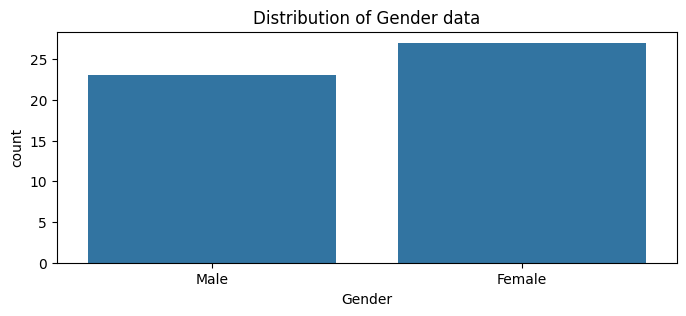

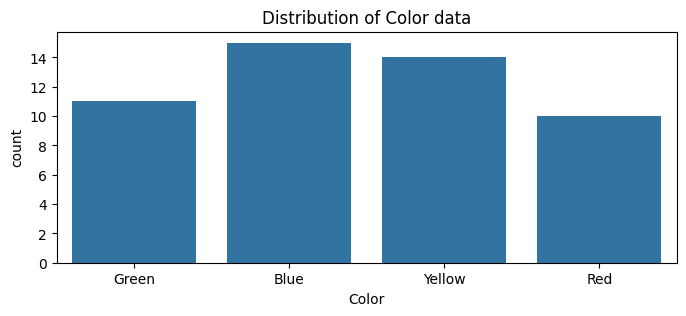

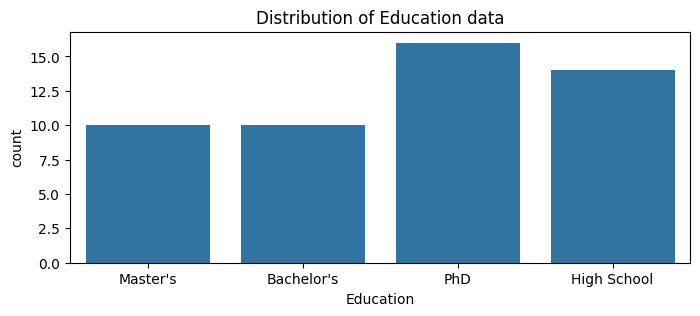

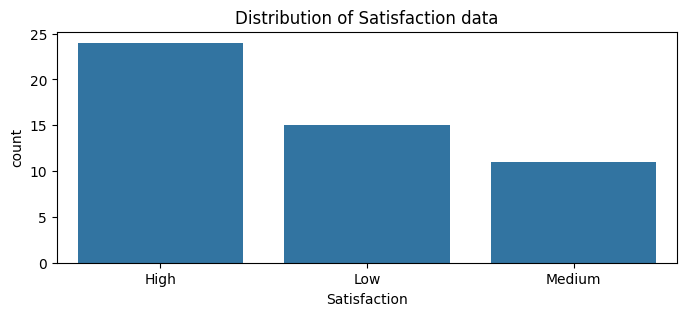

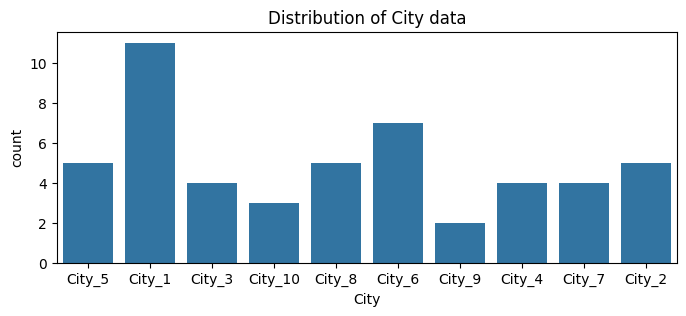

In [7]:
cat_cols = df.select_dtypes(include='object').columns
#What it does:

# Picks columns with dtype = "object" → usually categorical text data
# Example result: ['Gender', 'Color', 'Education', 'Satisfaction', 'City']
#it wont include numerical like HasCar which is binary but stored as int

for label in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=label, data=df)
    plt.title(f'Distribution of {label} data')
    plt.show() #renders the graph

If we dont find any Outliers here then we will go for different types of encoding

1️⃣ One-Hot Encoding (OHE)
Create one binary column per category
Example
| Color | → | Red | Blue | Green |
| ----- | - | --- | ---- | ----- |
| Red   |   | 1   | 0    | 0     |
| Blue  |   | 0   | 1    | 0     |

✔ Best for:

Nominal data (no order)
Low cardinality (few categories)

❌ Problem:

Too many columns if categories are large (like City)

2️⃣ Label Encoding
Assign integer to each category based on alphabetical order of lebels
Red = 0, Blue = 1, Green = 2
⚠️ Problem:

Model assumes order exists
Green (2) > Blue (1) → which is wrong

3️⃣ Ordinal Encoding

Assign numbers based on actual order
Low = 1, Medium = 2, High = 3


4️⃣ Frequency / Count Encoding
Replace category with its frequency

Example:
| City   | Count |
| ------ | ----- |
| City_1 | 100   |
| City_2 | 50    |


5️⃣ Target Encoding (Mean Encoding)
Replace category with mean of target variable

| Gender | Avg(target) |
| ------ | ----------- |
| Male   | 0.3         |
| Female | 0.6         |


In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [9]:
cat_cols

Index(['Gender', 'Color', 'Education', 'Satisfaction', 'City'], dtype='str')

In [10]:
ordinal_cols = ['Education', 'Satisfaction']

education_order = ['High School', "Bachelor's", "Master's", 'PhD']
satisfaction_order = ['Low', 'Medium', 'High']

# So internally:

# Education →
# High School = 0
# Bachelor’s = 1
# Master’s = 2
# PhD = 3
# Satisfaction →
# Low = 0
# Medium = 1
# High = 2

ordinal_encoder = OrdinalEncoder(categories=[education_order, satisfaction_order])
# ⚠️ Important:

# Order of categories must match order of columns: ['Education', 'Satisfaction']

ordinal_encoded = ordinal_encoder.fit_transform(df[ordinal_cols])
# fit() → learns mapping
# transform() → applies mapping
# Output:

# A NumPy array like:
# [[2, 1],
#  [1, 0],
#  [3, 2]]

# To convert back to data frame with column names:
df_ordinal_encoded = pd.DataFrame(ordinal_encoded, columns=[f"{c}_encoded" for c in ordinal_cols])

df_ordinal_encoded

,Education_encoded,Satisfaction_encoded
0,2.0,2.0
1,1.0,2.0
2,1.0,0.0
3,3.0,2.0
4,1.0,0.0
5,1.0,1.0
6,1.0,2.0
7,3.0,1.0
8,1.0,0.0
9,2.0,2.0


In [11]:
df = pd.concat([df, df_ordinal_encoded], axis=1)
df

,Gender,Color,Education,Satisfaction,HasCar,City,Education_encoded,Satisfaction_encoded
0,Male,Green,Master's,High,0,City_5,2.0,2.0
1,Female,Blue,Bachelor's,High,0,City_1,1.0,2.0
2,Male,Green,Bachelor's,Low,0,City_3,1.0,0.0
3,Male,Yellow,PhD,High,0,City_10,3.0,2.0
4,Male,Green,Bachelor's,Low,1,City_8,1.0,0.0
5,Female,Yellow,Bachelor's,Medium,0,City_6,1.0,1.0
6,Male,Yellow,Bachelor's,High,1,City_8,1.0,2.0
7,Male,Red,PhD,Medium,0,City_9,3.0,1.0
8,Male,Green,Bachelor's,Low,0,City_4,1.0,0.0
9,Female,Red,Master's,High,0,City_1,2.0,2.0
